In [1]:
import numpy as np
from scipy import constants
import pandas as pd
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
NA = 0.1
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

[1.47e+08 1.40e+08]


In [2]:
transitions_full = pd.read_csv("Ca_level_info.csv",sep = ",",encoding = "UTF-8")
linewidths_full = np.array(transitions_full["A_ki (s^-1)"])
lambda_res_full = np.array(transitions_full["wavelength (nm)"])*1e-9
omega_res_full = 2*pi*c/lambda_res_full
linewidths_full

array([2.58e+07, 1.72e+06, 2.34e+06, 3.52e+07, 4.91e+07, 3.28e+06,
       7.10e+07, 4.73e+06, 7.20e+06, 1.07e+08, 1.30e+06, 1.73e+07,
       2.60e+08, 1.80e+06, 1.47e+08, 1.40e+08, 1.30e+00, 1.30e+00,
       9.90e+06])

# 3 ions, no tweezers, modes as bar chart

In [3]:
N = 3
tweezed_ions = []
w_rf_a = 2*pi*1e6
w_rf_r = 2*pi*3e6
ueq = ion_spacing(N, w_rf_a)[0]
P_opt = 0
w0 = 1e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt,w0)
radial_modes = physical_params_to_radial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
axial_modes = physical_params_to_axial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
etas_axial = eta(axial_modes,tweezer_wavelength,N)
etas_radial = eta(radial_modes,tweezer_wavelength,N)


# Convert axial_modes_base to a table
data_axial = {
    "Frequency (Hz)": [entry[0] for entry in axial_modes],
}
data_radial = {
    "Frequency (Hz)": [entry[0] for entry in radial_modes],
}
# Add columns for each component of the mode vectors
for i in range(len(etas_axial[0])):  # Iterate over the number of components in each mode vector
    data_axial[f"Component {i+1}"] = [eta[i] for eta in etas_axial]
for i in range(len(etas_radial[0])):  # Iterate over the number of components in each mode vector
    data_radial[f"Component {i+1}"] = [eta[i] for eta in etas_radial]

    

In [4]:
print(data_radial)

{'Frequency (Hz)': [3000000.0, 2828427.1247461913, 2569046.5157330246], 'Component 1': [0.11097333743663125, 0.13997562245881176, -0.08479657145125706], 'Component 2': [0.11097333743663118, -1.1685662969922638e-14, 0.16959314290253547], 'Component 3': [0.11097333743663092, -0.13997562245880002, -0.08479657145127838]}


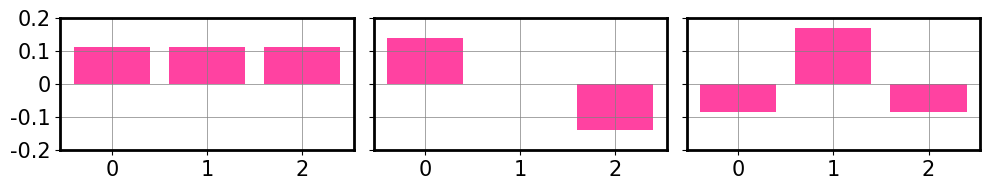

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=N, figsize=(10, 2), dpi=100)  # Adjusted figsize and dpi

# Loop through each mode and plot
for i in range(N):  # Single row for modes 0 to N-1
    ion_numbers = np.arange(0, N)  # Ion indices
    ax = axes[i]  # Get the current axis

    # Plot the eta values for the current mode
    ax.bar(ion_numbers, etas_radial[i], color='#FF42A1')  # Use etas_radial[i] directly for bar heights
    ax.set_ylim(-0.2, 0.2)  # Adjust y-axis limits as needed

    # Set x-ticks for every ion
    ax.set_xticks(ion_numbers)  # Show every ion number
    ax.set_xticklabels(ion_numbers, fontsize=15)  # Set larger font size for x-tick labels

    # Set y-ticks for all plots but only show labels for the leftmost plot
    ax.set_yticks([-0.2, -0.1, 0, 0.1, 0.2])  # Set specific y-tick positions
    if i == 0:
        ax.set_yticklabels([-0.2, -0.1, 0, 0.1, 0.2], fontsize=15)  # Show y-tick labels for the leftmost plot
    else:
        ax.set_yticklabels([])  # Hide y-tick labels for other plots

    # Set thicker axes lines
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(2)

    # Add gridlines
    ax.grid(True, which='both', axis='both', color='gray', linestyle='-', linewidth=0.5)

    # Set tick labels fontsize
    ax.tick_params(axis='both', which='major', labelsize=15)  # Increased tick mark font size

# Use tight layout to adjust spacing
fig.tight_layout()

plt.show()

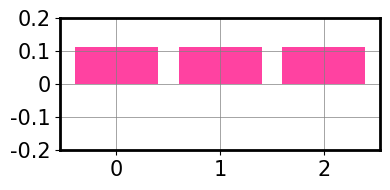

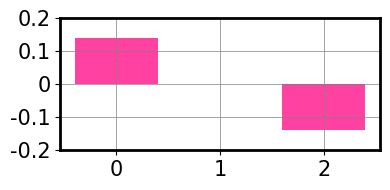

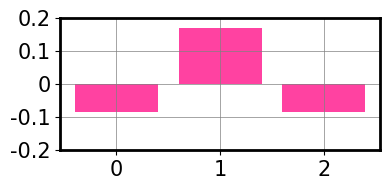

In [6]:
for i in range(N):  # Loop through each mode
    ion_numbers = np.arange(0, N)  # Ion indices

    # Create a new figure for each mode
    fig, ax = plt.subplots(figsize=(10/2.5, 2), dpi=100)  # Adjust figsize and dpi as needed

    # Plot the eta values for the current mode
    ax.bar(ion_numbers, etas_radial[i], color='#FF42A1')  # Use etas_radial[i] directly for bar heights
    ax.set_ylim(-0.2, 0.2)  # Adjust y-axis limits as needed

    # Set x-ticks for every ion
    ax.set_xticks(ion_numbers)  # Show every ion number
    ax.set_xticklabels(ion_numbers, fontsize=15)  # Set font size for x-tick labels

    # Set y-ticks
    ax.set_yticks([-0.2, -0.1, 0, 0.1, 0.2])  # Set specific y-tick positions
    ax.set_yticklabels([-0.2, -0.1, 0, 0.1, 0.2], fontsize=15)  # Set font size for y-tick labels

    # Set thicker axes lines
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(2)

    # Add gridlines
    ax.grid(True, which='both', axis='both', color='gray', linestyle='-', linewidth=0.5)


    # Use tight layout to adjust spacing
    fig.tight_layout()

    # Show the plot
    plt.show()

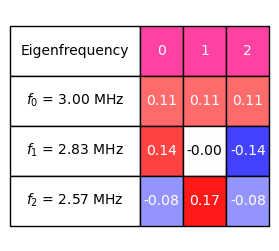

In [7]:
fig, ax = plt.subplots(figsize=(1, 1 * len(radial_modes)))
ax.axis('tight')
ax.axis('off')

maximum = max(max(etas_radial))
min = -1*maximum

# Adding a table
table_data = []
for index, (omega, values) in enumerate(radial_modes):
    # Convert omega from radians per second to MHz
    omega_mhz = (omega  / 1e6)
    formatted_values = [f"{eta:.2f}" for eta in etas_radial[index]]  # Use etas_radial for the cell values
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ['Eigenfrequency'] + [f"{i}" for i in range(len(etas_radial[0]))]

# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(etas_radial[0]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=min-0.05, vmax=maximum+0.05)

# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.07 < value < 0.07 else 'white')
        table[0,i].set_text_props(color='white')  # Keep the first column text color black

# Set gray background for the first row, excluding the top left corner cell
for j in range(1, len(column_labels)):  # Skip the top left corner cell
    table[0, j].set_facecolor('#FF42A1')
table[0, 0].set_facecolor('white')  # Keep the top left corner cell white

# Show the plot
plt.show()

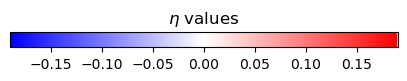

In [8]:
# Create a figure and axis for the color bar
fig, ax = plt.subplots(figsize=(5,0.2))
fig.subplots_adjust(bottom=0.1)
plt.title("$\eta$ values")

# Create a color bar
cbar = mcolorbar.ColorbarBase(ax, cmap=cmap,
                              norm=norm,
                              orientation='horizontal')
# Add y-tick marks at the min and max

cbar.set_label('')
plt.show()

# 8 circles equally spaced in a line

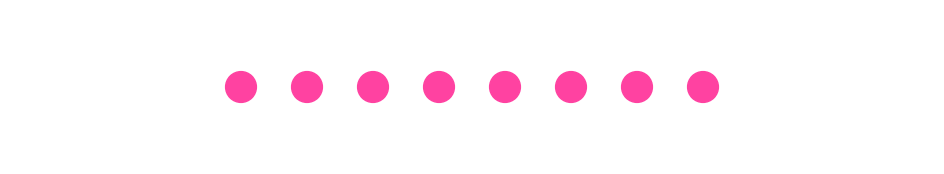

In [12]:
# Number of circles
num_circles = 8

# Circle parameters
radius = 0.1  # Radius of each circle
spacing = 0.5  # Spacing between circles
y_position = 0  # Fixed y-coordinate for all circles

# Calculate the x-coordinates for the circles
x_coords = np.linspace(-1.5, 1.5, num_circles)  # Equally spaced x-coordinates

# Create the plot
fig, ax = plt.subplots(figsize=(20, 2))

# Plot the circles
for x in x_coords:
    circle = plt.Circle((x, y_position), radius, color='#FF42A1', zorder=2)  # Circle with fixed radius
    ax.add_artist(circle)

# Set equal aspect ratio
ax.set_aspect('equal')

# Set limits for better visualization
ax.set_xlim(-3, 3)
ax.set_ylim(-0.5, 0.5)

# Remove axes for a cleaner look
ax.axis('off')

# Show the plot
plt.show()

# 9 circles in a line

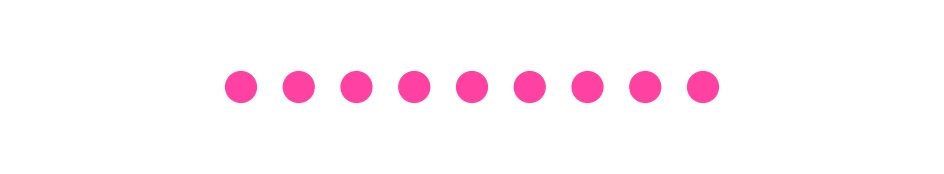

In [13]:
# Number of circles
num_circles = 9

# Circle parameters
radius = 0.1  # Radius of each circle
spacing = 0.5  # Spacing between circles
y_position = 0  # Fixed y-coordinate for all circles

# Calculate the x-coordinates for the circles
x_coords = np.linspace(-1.5, 1.5, num_circles)  # Equally spaced x-coordinates

# Create the plot
fig, ax = plt.subplots(figsize=(20, 2))

# Plot the circles
for x in x_coords:
    circle = plt.Circle((x, y_position), radius, color='#FF42A1', zorder=2)  # Circle with fixed radius
    #middle = plt.Circle((x_coords[tweezed_ions[0]], y_position), radius, color="green", zorder=2)
    ax.add_artist(circle)
    #ax.add_artist(middle)
    
# Set equal aspect ratio
ax.set_aspect('equal')

# Set limits for better visualization
ax.set_xlim(-3, 3)
ax.set_ylim(-0.5, 0.5)

# Remove axes for a cleaner look
ax.axis('off')

# Show the plot
plt.show()

# modes for 8 ions, no tweeezers yet

In [12]:
N = 9
tweezed_ions = []
w_rf_a = 2*pi*0.3*1e6
w_rf_r = 2*pi*3e6
ueq = ion_spacing(N, w_rf_a)[0]
P_opt = 0
w0 = 1e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt,w0)
radial_modes = physical_params_to_radial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
axial_modes = physical_params_to_axial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
etas_axial = eta(axial_modes,tweezer_wavelength,N)
etas_radial = eta(radial_modes,tweezer_wavelength,N)


# Convert axial_modes_base to a table
data_axial = {
    "Frequency (Hz)": [entry[0] for entry in axial_modes],
}
data_radial = {
    "Frequency (Hz)": [entry[0] for entry in radial_modes],
}
# Add columns for each component of the mode vectors
for i in range(len(etas_axial[0])):  # Iterate over the number of components in each mode vector
    data_axial[f"Component {i+1}"] = [eta[i] for eta in etas_axial]
for i in range(len(etas_radial[0])):  # Iterate over the number of components in each mode vector
    data_radial[f"Component {i+1}"] = [eta[i] for eta in etas_radial]

    

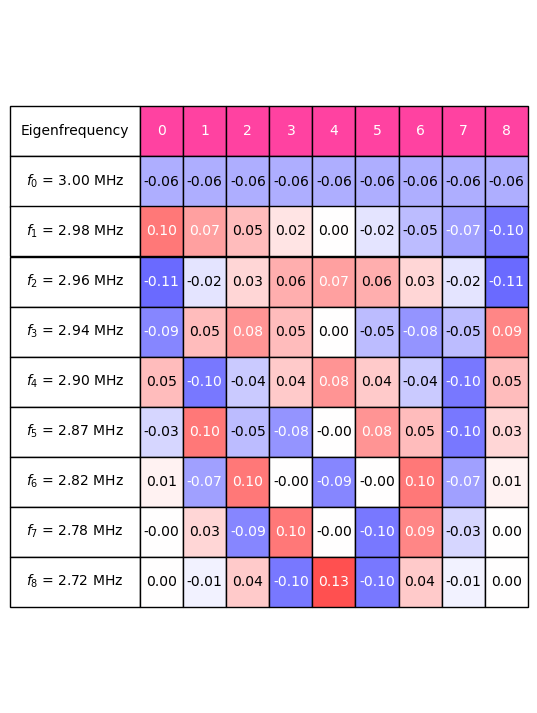

In [13]:
fig, ax = plt.subplots(figsize=(1, 1 * len(radial_modes)))
ax.axis('tight')
ax.axis('off')

# Adding a table
table_data = []
for index, (omega, values) in enumerate(radial_modes):
    # Convert omega from radians per second to MHz
    omega_mhz = (omega  / 1e6)
    formatted_values = [f"{eta:.2f}" for eta in etas_radial[index]]  # Use etas_radial for the cell values
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ['Eigenfrequency'] + [f"{i}" for i in range(len(etas_radial[0]))]

# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(etas_radial[0]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=min-0.05, vmax=maximum+0.05)

# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.07 < value < 0.07 else 'white')
        table[0,i].set_text_props(color='white')  # Keep the first column text color black

# Set gray background for the first row, excluding the top left corner cell
for j in range(1, len(column_labels)):  # Skip the top left corner cell
    table[0, j].set_facecolor('#FF42A1')
table[0, 0].set_facecolor('white')  # Keep the top left corner cell white

# Show the plot
plt.show()

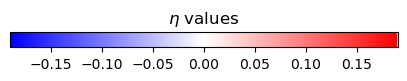

In [11]:
# Create a figure and axis for the color bar
fig, ax = plt.subplots(figsize=(5,0.2))
fig.subplots_adjust(bottom=0.1)
plt.title("$\eta$ values")

# Create a color bar
cbar = mcolorbar.ColorbarBase(ax, cmap=cmap,
                              norm=norm,
                              orientation='horizontal')
# Add y-tick marks at the min and max

cbar.set_label('')
plt.show()

# Potential vs beam waist -- bottom window -- realistic params

In [19]:
lam = 532*1e-9
omegas_twz = 2*pi*c/lam
Popt = 0.5
w0s = np.linspace(0.2,2,100)*1e-6

U = potential(lam,linewidths,omega_res,Popt,w0s)
w_twz_r,w_twz_a = tweezer_optical_potential_to_trap_frequency(lam,linewidths,omega_res,Popt,w0s,m,U)
s = scattering(omega_tweezer,linewidths,omega_res,Popt,w0s)

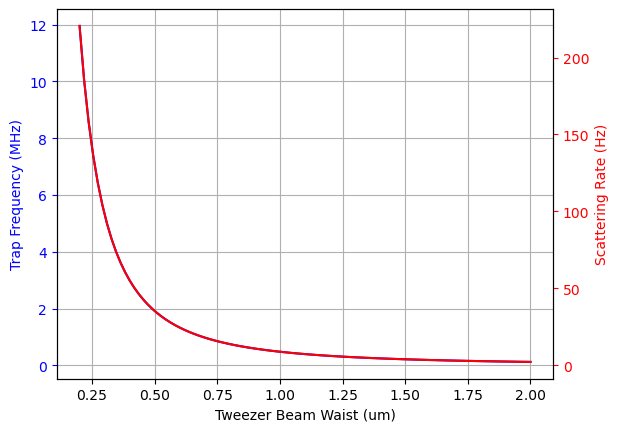

In [20]:
fig,ax = plt.subplots(1,1,dpi=100)

ax.plot(w0s*1e6,w_twz_r*1e-6/(2*np.pi),'b')

ax2=ax.twinx()
ax2.plot(w0s*1e6,s/(2*pi),'r')

#ax.set_ylim(0,500)
#ax2.set_ylim(0,12)

ax.set_xlabel('Tweezer Beam Waist (um)')
ax.set_ylabel('Trap Frequency (MHz)',color='b')
ax2.set_ylabel('Scattering Rate (Hz)',color='r')

ax.tick_params(axis='y', colors='b')
ax2.tick_params(axis='y', colors='r')

ax.grid()
plt.savefig("BeamWaist_Sweep_Freq_Scatter.png")
plt.show() 

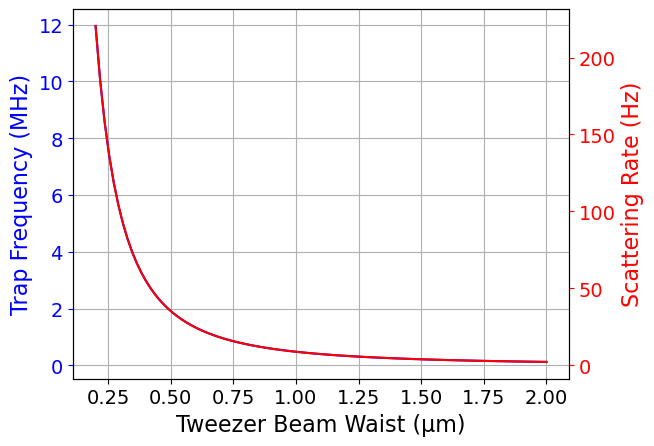

In [21]:
fig, ax = plt.subplots(1, 1, dpi=100)

# Plot trap frequency
ax.plot(w0s * 1e6, w_twz_r * 1e-6 / (2 * np.pi), 'b')

# Add secondary y-axis for scattering rate
ax2 = ax.twinx()
ax2.plot(w0s * 1e6, s / (2 * np.pi), 'r')

# Set axis labels with larger font size
ax.set_xlabel('Tweezer Beam Waist (µm)', fontsize=16)
ax.set_ylabel('Trap Frequency (MHz)', color='b', fontsize=16)
ax2.set_ylabel('Scattering Rate (Hz)', color='r', fontsize=16)

# Increase tick label font size
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14, colors='b')
ax2.tick_params(axis='y', labelsize=14, colors='r')

# Add grid
ax.grid()

# Save and show the plot
plt.show()

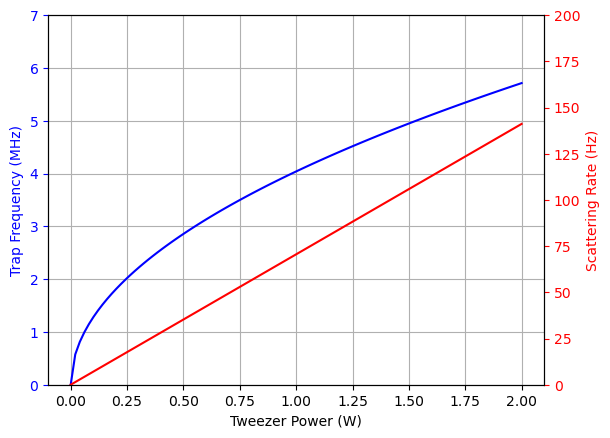

In [22]:
lam = 532*1e-9
omegas_twz = 2*pi*c/lam
Popts = np.linspace(0,2,100)
w0 = 0.5e-6

U = potential(omegas_twz,linewidths,omega_res,Popts,w0)
w_twz_r,w_twz_a = tweezer_optical_potential_to_trap_frequency(lam,linewidths,omega_res,Popts,w0,m,U)
s = scattering(omegas_twz,linewidths,omega_res,Popts,w0)
fig,ax = plt.subplots(1,1,dpi=100)

ax.plot(Popts,w_twz_r*1e-6/(2*np.pi),'b')

ax2=ax.twinx()
ax2.plot(Popts,s/(2*pi),'r')

ax.set_ylim(0,7)
ax2.set_ylim(0,200)

ax.set_xlabel('Tweezer Power (W)')
ax.set_ylabel('Trap Frequency (MHz)',color='b')
ax2.set_ylabel('Scattering Rate (Hz)',color='r')

ax.tick_params(axis='y', colors='b')
ax2.tick_params(axis='y', colors='r')

ax.grid()
plt.savefig("Power_Sweep_Freq_Scatter.png")
plt.show()

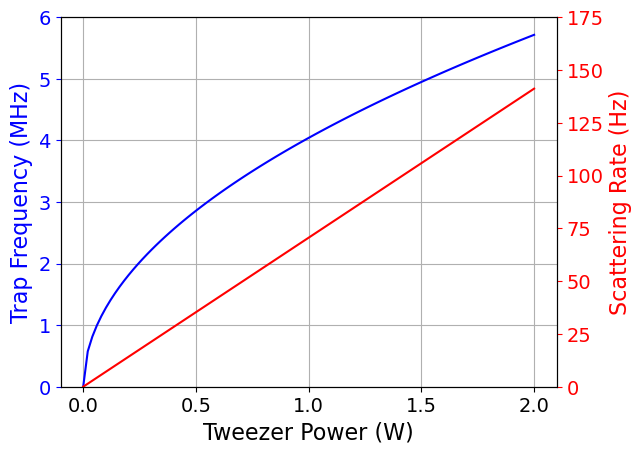

In [23]:
fig, ax = plt.subplots(1, 1, dpi=100)

# Plot trap frequency
ax.plot(Popts, w_twz_r * 1e-6 / (2 * np.pi), 'b')

# Add secondary y-axis for scattering rate
ax2 = ax.twinx()
ax2.plot(Popts, s / (2 * np.pi), 'r')

# Set y-axis limits
ax.set_ylim(0, 6)
ax2.set_ylim(0, 175)

# Set axis labels with larger font size
ax.set_xlabel('Tweezer Power (W)', fontsize=16)
ax.set_ylabel('Trap Frequency (MHz)', color='b', fontsize=16)
ax2.set_ylabel('Scattering Rate (Hz)', color='r', fontsize=16)

# Increase tick label font size
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14, colors='b')
ax2.tick_params(axis='y', labelsize=14, colors='r')
# Reduce the number of ticks on ax2
ax2.yaxis.set_major_locator(plt.MaxNLocator(nbins=7))  # Half as many ticks

# Add grid
ax.grid()

# Save and show the plot
plt.savefig("Power_Sweep_Freq_Scatter.png")
plt.show()

# 8 ions, high power tweezer in the middle to split the chain into two subchains

In [24]:
N = 9
tweezed_ions = [4]
w_rf_a = 2*pi*0.3e6
w_rf_r = 2*pi*2e6
ueq = ion_spacing(N, w_rf_a)[0]
P_opt = 0.5
w0 = 0.5e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt,w0)
radial_modes = physical_params_to_radial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
axial_modes = physical_params_to_axial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
etas_axial = eta(axial_modes,tweezer_wavelength,N)
etas_radial = eta(radial_modes,tweezer_wavelength,N)


# Convert axial_modes_base to a table
data_axial = {
    "Frequency (Hz)": [entry[0] for entry in axial_modes],
}
data_radial = {
    "Frequency (Hz)": [entry[0] for entry in radial_modes],
}
# Add columns for each component of the mode vectors
for i in range(len(etas_axial[0])):  # Iterate over the number of components in each mode vector
    data_axial[f"Component {i+1}"] = [eta[i] for eta in etas_axial]
for i in range(len(etas_radial[0])):  # Iterate over the number of components in each mode vector
    data_radial[f"Component {i+1}"] = [eta[i] for eta in etas_radial]

    

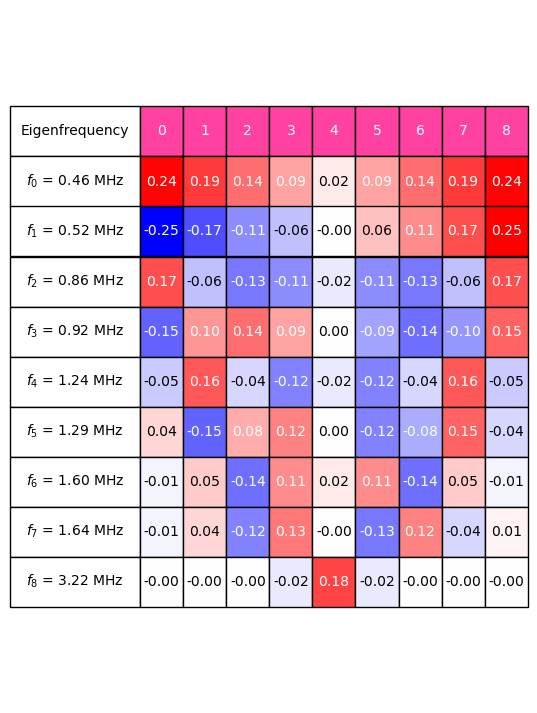

In [25]:
fig, ax = plt.subplots(figsize=(1, 1 * len(axial_modes)))
ax.axis('tight')
ax.axis('off')

# Adding a table
table_data = []
for index, (omega, values) in enumerate(axial_modes):
    # Convert omega from radians per second to MHz
    omega_mhz = (omega  / 1e6)
    formatted_values = [f"{eta:.2f}" for eta in etas_axial[index]]  # Use etas_radial for the cell values
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ['Eigenfrequency'] + [f"{i}" for i in range(len(etas_axial[0]))]

# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(etas_axial[0]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=-max(max(etas_axial))-0.01, vmax=max(max(etas_axial))+0.01)

# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.07 < value < 0.07 else 'white')
        table[0,i].set_text_props(color='white')  # Keep the first column text color black        

# Set gray background for the first row, excluding the top left corner cell
for j in range(1, len(column_labels)):  # Skip the top left corner cell
    table[0, j].set_facecolor('#FF42A1')
table[0, 0].set_facecolor('white')  # Keep the top left corner cell white
#table[0,4].set_facecolor('gray') 

# Show the plot
plt.show()

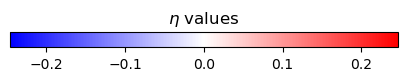

In [ ]:
# Create a figure and axis for the color bar
fig, ax = plt.subplots(figsize=(5,0.2))
fig.subplots_adjust(bottom=0.1)
plt.title("$\eta$ values")

# Create a color bar
cbar = mcolorbar.ColorbarBase(ax, cmap=cmap,
                              norm=norm,
                    
                    
                    
                              orientation='horizontal')
# Add y-tick marks at the min and max

cbar.set_label('')
plt.show()

# Misalignment figs

In [27]:
N = 1
#x = np.empty(N)
omega_rf_axial = 1 * 1 * pi * 1e6
ionspacing = ion_spacing(N,omega_rf_axial)
P0 = 1
beam_waist = 1e-6
U = potential(omega_tweezer,linewidths,omega_res,P0,beam_waist)
omega_tw_radial = tweezer_optical_potential_to_trap_frequency(omega_tweezer,linewidths,omega_res,P0,beam_waist,m,U)[0]
#print(omega_tw_radial)
tweezed_ion = 0
displacement = beam_waist * 0.9

tweeze_on = fsolve(pot_derivative_with_tweeze,ionspacing[0],args = (omega_rf_axial,omega_tw_radial,tweezed_ion,displacement))
print(tweeze_on)
print(ionspacing)
ionspacing[0] == fsolve(pot_derivative_with_tweeze,ionspacing[0],args = (omega_rf_axial,omega_tw_radial,tweezed_ion,displacement))

(tweeze_on[0] - ionspacing[0][tweezed_ion])*1e9

[7.22812074e-07]
[array([0.]), []]


722.8120739390333

[-6.67934432e-25  1.33515109e-12] [[ 7.56683955e-65 -2.01406819e-49]
 [-2.01406819e-49  9.65977710e-34]]


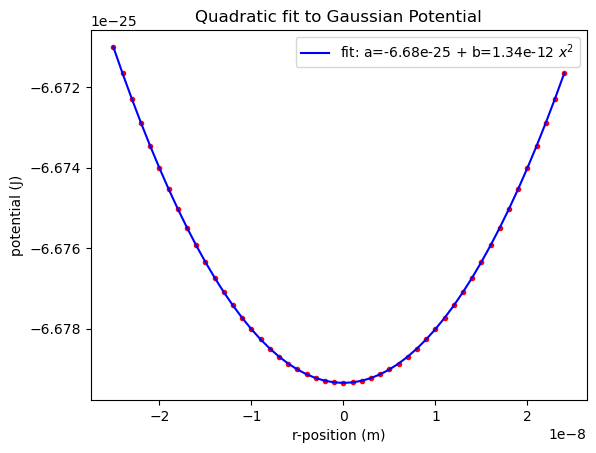

In [28]:
P0 = 1
w0 = 1e-6
lambda_beam = 532e-9
lambda_beam = 532e-9
z_pos = 0
wz = beam_propogation(w0,z_pos, lambda_beam)

#making a list of positions to pass through the potential function.  This is in the frame of the laser beam,
#so 0 is the center of the beam
x_pos = np.arange((1/2)*-0.05*1e-6,(1/2)*(0.05)*1e-6,0.001e-6)
y_pos = 0


intens = intensity(x_pos,y_pos,P0, wz)
a =  potential_position_dependent(omega_res,linewidths,omega_tweezer,intens)                      
#fitting the potential vector to a quadratic function
from scipy import optimize

def quadratic(x,a,b):
    return a+b*(x**2)
xdata = x_pos
ydata = a

popt, pcov = curve_fit(quadratic, xdata, ydata)

print(popt,pcov)

plt.plot(xdata,ydata,'r.')
plt.plot(xdata,quadratic(xdata, *popt) ,'b-',label=f'fit: a={popt[0]:.2e} + b={popt[1]:.2e} $x^{{2}}$')
plt.xlabel("r-position (m)")
plt.ylabel("potential (J)")
plt.title("Quadratic fit to Gaussian Potential")
plt.legend()
plt.show()

1.0
[-6.67934432e-25  1.33515109e-12] [[ 7.56683955e-65 -2.01406819e-49]
 [-2.01406819e-49  9.65977710e-34]]


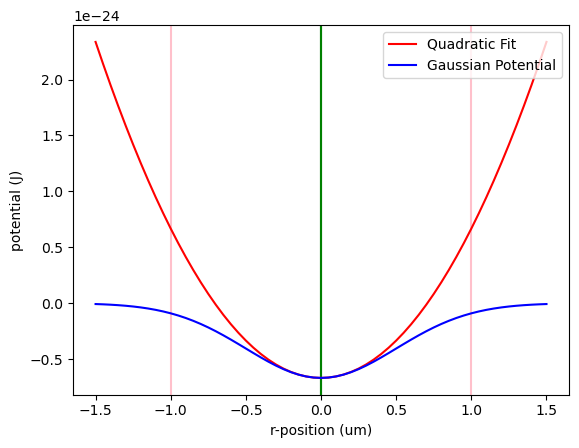

In [29]:
P0 = 1
w0 = 1e-6
lambda_beam = 532e-9
lambda_beam = 532e-9
z_pos = 0
wz = beam_propogation(w0,z_pos, lambda_beam)
x_pos = np.arange((-1.5)*1e-6,(1.5)*1e-6,0.05e-6)
dial_values = np.arange(0, 1.1, 0.05)
print(dial_values[20])
y_pos = x_pos
y_pos = 0
intens = intensity(x_pos,y_pos,P0, wz)
intens_0 = intensity(0,0,P0,wz)
popt, pcov = curve_fit(quadratic, xdata, ydata)

print(popt,pcov)

a =  potential_position_dependent(omega_res,linewidths,omega_tweezer,intens)  
plt.axvline(x=(w0 ) * (dial_values[0] + dial_values[00] * 0.025)*1e6, color='g', linestyle='-')   
plt.axvline(x=(w0 ) * (dial_values[00] - dial_values[00] * 0.025)*1e6, color='g', linestyle='-') 
plt.axvline(x = w0*1e6,color = 'pink')
plt.axvline(x = -w0*1e6,color = 'pink') 
plt.xlabel("r-position (um)")
plt.ylabel("potential (J)") 
plt.plot(x_pos*1e6,quadratic(x_pos, *popt) ,'r-',label="Quadratic Fit")
plt.plot(x_pos*1e6,a,'b-',label = "Gaussian Potential")
plt.legend(loc = 'upper right')
plt.savefig("Gaussian_Potential_Quad_Fit.png")
plt.show()

11
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
[-1.e-08  0.e+00  1.e-08]
[9.750e-08 1.000e-07 1.025e-07]
[1.95e-07 2.00e-07 2.05e-07]
[2.925e-07 3.000e-07 3.075e-07]
[3.9e-07 4.0e-07 4.1e-07]
[4.875e-07 5.000e-07 5.125e-07]
[5.85e-07 6.00e-07 6.15e-07]
[6.825e-07 7.000e-07 7.175e-07]
[7.8e-07 8.0e-07 8.2e-07]
[8.775e-07 9.000e-07 9.225e-07]
[9.750e-07 1.000e-06 1.025e-06]


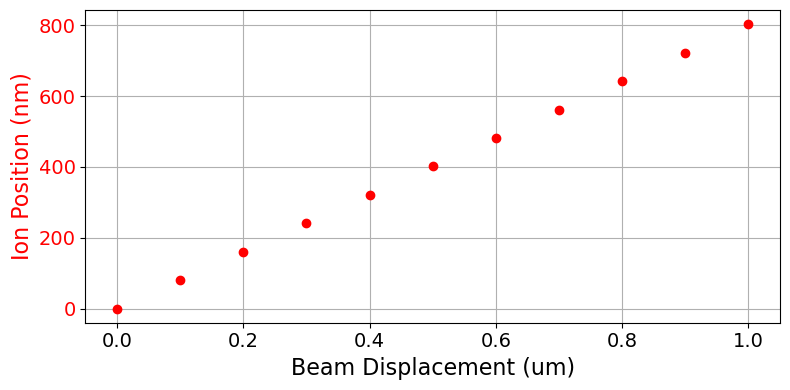

Fit-Based Radial Frequencies: [1.0098199044354967, 0.9998148106201019, 0.9702458068880687, 0.9228977124324411, 0.8604727519680189, 0.786385456861247, 0.7044538208939404, 0.6185760015343877, 0.5324302565447281, 0.44922923984920893, 0.37154917515484165]
Ion Positions (nm): [  0.          80.31245266 160.62490532 240.93735798 321.24981064
 401.5622633  481.87471596 562.18716862 642.49962128 722.81207394
 803.1245266 ]


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, fsolve

# Constants
#dial_values = np.arange(0, 1.1, 0.05)
dial_values = np.arange(0,1.1,0.1) #for testing
print(len(dial_values))
print(dial_values)
results = []
fits = []  # To store the fit-based radial frequencies
errors = []  # To store the errors for the fit
P0 = 1
w0 = 1e-6
lambda_beam = 532e-9
z_pos = 0
wz = beam_propogation(w0, z_pos, lambda_beam)
positions = []
r_pos_save = []

num_points = 3  # Define the number of points for `r_pos`

for dial in dial_values:
    # Calculate r_pos for each dial value
    if dial == 0:
        r_max = 0.001e-5
        r_min = -0.001e-5
    else:
        r_max = (w0 ) * (dial + dial * 0.025)
        r_min = (w0 ) * (dial - dial * 0.025)
    r_pos = np.linspace(r_min, r_max, num_points)
    print(r_pos)
    r_pos_save.append(r_pos)
    x_pos = r_pos
    y_pos = 0

    # Calculate ydata based on r_pos
    ydata = potential_position_dependent(omega_res, linewidths, omega_tweezer, intensity(x_pos, y_pos, P0, wz))

    # Directly use r_pos and ydata for fitting (assuming they always match in length)
    xdata = r_pos
    popt, pcov = curve_fit(quadratic, xdata, ydata)

    # Calculate the fit-based radial frequency
    fit = np.sqrt(2 * popt[1] / m)

    # Estimate error from the covariance matrix for popt[1]
    perr = np.sqrt(np.diag(pcov))
    fit_error = np.abs(fit * (perr[1] / popt[1]))

    # Store the fit and its error
    fits.append(fit*1e-6/(2*pi)) # making sure the fit is kHz, and is regular frequency not angular frequency 
    errors.append(fit_error*1e-6)

    # Displacement and ion position
    displacement = w0 * dial
    U = potential(omega_tweezer, linewidths, omega_res, P0, w0)
    omega_tw_radial = tweezer_optical_potential_to_trap_frequency(omega_tweezer, linewidths, omega_res, P0, w0, m, U)[0]
    tweeze_on = fsolve(pot_derivative_with_tweeze, ionspacing[0], args=(omega_rf_axial, omega_tw_radial, tweezed_ion, displacement))
    positions.append(tweeze_on[0])

# Convert positions to nanometers
positions = np.array(positions) * 1e9  # Convert to nm

# Plotting
fig, ax = plt.subplots(figsize=(8, 4))


ax.set_xlabel('Beam Displacement (um)',fontsize = '16')

ax.tick_params(axis='x', left=False, labelleft=False,labelsize = '14')
#ax2.tick_params(axis='x', left=False, labelleft=False,labelsize = '14')

# Plot ion position on the right y-axis
#ax2 = ax1.twinx()
ax.plot(dial_values*w0*1e6, positions, 'o', color='red', label='Ion Equliubrium Position')
ax.set_ylabel('Ion Position (nm)', color='red',fontsize = '16')
ax.tick_params(axis='y', labelcolor='red',labelsize = '14')

# Add title and grid
#fig.suptitle('Radial Frequency and Ion Position vs Tweezer Misalignment')
ax.grid(True)
fig.tight_layout()

# Save and show the plot
#plt.savefig("Frequency_Position_Misalignment.png")
plt.show()

print("Fit-Based Radial Frequencies:", fits)
print("Ion Positions (nm):", positions)

[6.424996212791408e-07]
[6.424996212791408e-07, 6.437544674725836e-07]
[6.424996212791408e-07, 6.437544674725836e-07, 6.449894763476634e-07]
[6.424996212791408e-07, 6.437544674725836e-07, 6.449894763476634e-07, 6.46205114614693e-07]
[6.424996212791408e-07, 6.437544674725836e-07, 6.449894763476634e-07, 6.46205114614693e-07, 6.474018344575854e-07]
[6.424996212791408e-07, 6.437544674725836e-07, 6.449894763476634e-07, 6.46205114614693e-07, 6.474018344575854e-07, 6.485800740946593e-07]
[6.424996212791408e-07, 6.437544674725836e-07, 6.449894763476634e-07, 6.46205114614693e-07, 6.474018344575854e-07, 6.485800740946593e-07, 6.497402583136637e-07]
[6.424996212791408e-07, 6.437544674725836e-07, 6.449894763476634e-07, 6.46205114614693e-07, 6.474018344575854e-07, 6.485800740946593e-07, 6.497402583136637e-07, 6.508827989823924e-07]
[6.424996212791408e-07, 6.437544674725836e-07, 6.449894763476634e-07, 6.46205114614693e-07, 6.474018344575854e-07, 6.485800740946593e-07, 6.497402583136637e-07, 6.508827

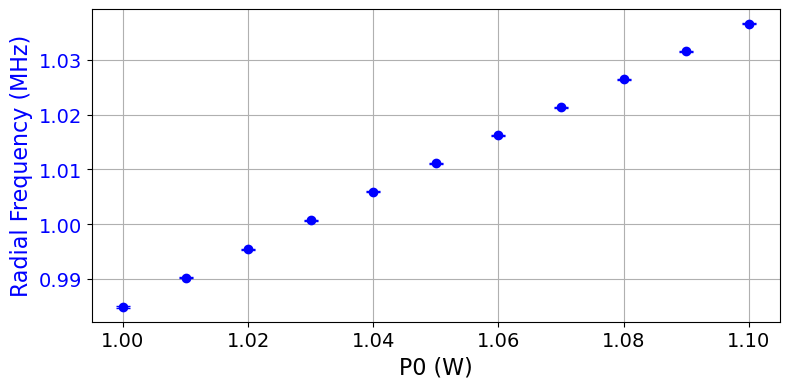

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Constants
P0_values = np.linspace(1, 1.1, 11)  # P0 values ranging from 1 W to 2 W
dial = 0.8  # Fixed dial value
w0 = 1e-6
lambda_beam = 532e-9
z_pos = 0
wz = beam_propogation(w0, z_pos, lambda_beam)
positions = []
r_pos_save = []
P0_analytical = 1  # Fixed P0 for analytical frequency calculation
results = []
frequencies = []  # To store the fit-based radial frequencies
errors = []  # To store the errors for the fit
num_points = 1000  # Fixed number of points for each P0 value

# Calculate the analytical frequency only once using P0_analytical
U = potential(omega_tweezer, linewidths, omega_res, P0_analytical, w0)
analytical = tweezer_optical_potential_to_trap_frequency(lambda_beam, linewidths, omega_res, P0_analytical, w0, m, U)

for P0 in P0_values:
    # Displacement and ion position
    displacement = w0 * dial
    U = potential(omega_tweezer, linewidths, omega_res, P0, w0)
    omega_tw_radial = tweezer_optical_potential_to_trap_frequency(omega_tweezer, linewidths, omega_res, P0, w0, m, U)[0]
    tweeze_on = fsolve(pot_derivative_with_tweeze, ionspacing[0], args=(omega_rf_axial, omega_tw_radial, tweezed_ion, displacement))
    positions.append(tweeze_on[0])
    print(positions)
    # Define r_pos for the current P0 value
    r_max = (w0 ) * (dial + dial * 0.025) - tweeze_on[0]
    r_min = (w0) * (dial - dial * 0.025) - tweeze_on[0]
    r_pos = np.linspace(r_min, r_max, num_points)

    # Recalculate ydata for each P0 value
    ydata = potential_position_dependent(omega_res, linewidths, omega_tweezer, intensity(r_pos, 0, P0, wz))

    # Use r_pos and ydata for fitting
    xdata = r_pos

    # Perform the fit for the potential
    popt, pcov = curve_fit(quadratic, xdata, ydata)

    # Calculate the fit-based radial frequency
    fit = np.sqrt(2 * popt[1] / m)

    # Estimate error from the covariance matrix for popt[1]
    perr = np.sqrt(np.diag(pcov))
    fit_error = np.abs(fit * (perr[1] / popt[1]))



    # Store the fit frequency and its error
    frequencies.append(fit * 1e-6 / (2 * np.pi))  # Convert to MHz
    errors.append(fit_error * 1e-6 / (2 * np.pi))  # Convert to MHz


# Convert positions to nanometers
positions = np.array(positions) * 1e9  # Convert to nm
# Plotting
fig, ax = plt.subplots(figsize=(8, 4))
ax.tick_params(axis='x', left=False, labelleft=False,labelsize = '14')
ax.tick_params(axis='y', labelcolor='blue',labelsize = '14')

# Plot fit-based radial frequency on the left y-axis
ax.errorbar(P0_values, frequencies, yerr=errors, fmt='o', label='Fit-Based Frequency', color='blue', capsize=5)
ax.set_xlabel('P0 (W)',fontsize = '16')
ax.set_ylabel('Radial Frequency (MHz)', color='blue',fontsize = '16')
ax.tick_params(axis='y', labelcolor='blue')

# Plot ion position on the right y-axis
#ax2 = ax1.twinx()
#ax2.plot(P0_values, positions, 'o', color='red', label='Ion Position')
#ax2.set_ylabel('Ion Position (nm)', color='red')
#ax2.tick_params(axis='y', labelcolor='red')
#ax2.set_ylim(0, 500) # want this y-axis to match the other one 

# Add title and grid
ax.grid(True)
fig.tight_layout()
plt.show()

11
0.0
0.1
0.2
0.30000000000000004
0.4
0.5
0.6000000000000001
0.7000000000000001
0.8
0.9
1.0


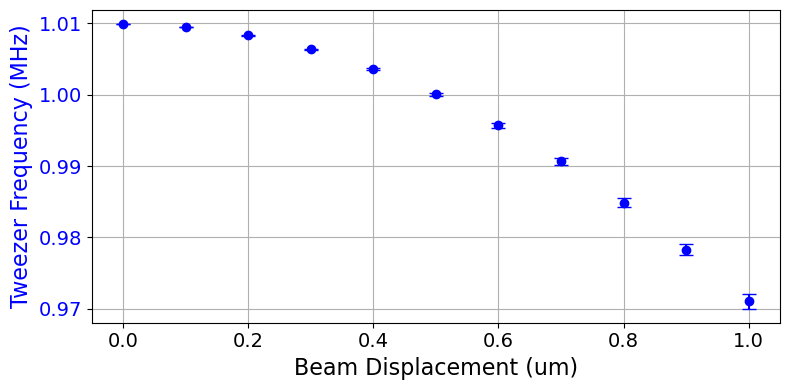

Fit-Based Radial Frequencies: [1.0098270306769954, 1.0094744144395653, 1.0082874250844451, 1.006312288473327, 1.003553759677684, 1.00001846798193, 0.9957148902123153, 0.9906533160475862, 0.9848458059600603, 0.9783061422207691, 0.9710497730067458]
Ion Positions (nm): [  0.          80.31245266 160.62490532 240.93735798 321.24981064
 401.5622633  481.87471596 562.18716862 642.49962128 722.81207394
 803.1245266 ]


In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, fsolve

# Constants
dial_values = np.arange(0, 1.1, 0.05)
dial_values = np.arange(0,1.1,0.1) #for testing
print(len(dial_values))
results = []
fits = []  # To store the fit-based radial frequencies
errors = []  # To store the errors for the fit
P0 = 1
w0 = 1e-6
lambda_beam = 532e-9
z_pos = 0
wz = beam_propogation(w0, z_pos, lambda_beam)
positions = []
r_pos_save = []

num_points = 1000  # Define the number of points for `r_pos`

for dial in dial_values:
    # Displacement and ion position
    displacement = w0 * dial
    print(dial)
    U = potential(omega_tweezer, linewidths, omega_res, P0, w0)
    omega_tw_radial = tweezer_optical_potential_to_trap_frequency(omega_tweezer, linewidths, omega_res, P0, w0, m, U)[0]
    tweeze_on = fsolve(pot_derivative_with_tweeze, ionspacing[0], args=(omega_rf_axial, omega_tw_radial, tweezed_ion, displacement))
    positions.append(tweeze_on[0])
    # Calculate r_pos for each dial value
    if dial == 0:
        r_max = 0.001e-5 - tweeze_on[0]
        r_min = -0.001e-5- tweeze_on[0]
    else:
        r_max = (w0 ) * (dial + dial * 0.025)- tweeze_on[0]
        r_min = (w0 ) * (dial - dial * 0.025)- tweeze_on[0]
    r_pos = np.linspace(r_min, r_max, num_points)
    r_pos_save.append(r_pos)
    #print(r_pos)
    x_pos = r_pos
    y_pos = 0
     # Calculate ydata based on new r_pos
    ydata = potential_position_dependent(omega_res, linewidths, omega_tweezer, intensity(x_pos, y_pos, P0, wz))

    # Directly use r_pos and ydata for fitting (assuming they always match in length)
    xdata = r_pos
    popt, pcov = curve_fit(quadratic, xdata, ydata)

    # Calculate the fit-based radial frequency
    fit = np.sqrt(2 * popt[1] / m)

    # Estimate error from the covariance matrix for popt[1]
    perr = np.sqrt(np.diag(pcov))
    fit_error = np.abs(fit * (perr[1] / popt[1]))

    # Store the fit and its error
    fits.append(fit*1e-6/(2*pi)) # making sure the fit is kHz, and is regular frequency not angular frequency 
    errors.append(fit_error*1e-6)

# Convert positions to nanometers
positions = np.array(positions) * 1e9  # Convert to nm

# Plotting
fig, ax1 = plt.subplots(figsize=(8, 4))

# Plot fit-based radial frequency on the left y-axis
ax1.errorbar(dial_values*w0*1e6, fits, yerr=errors, fmt='o', label='Fit-Based Radial Frequency', color='blue', capsize=5)
ax1.set_xlabel('Beam Displacement (um)', fontsize=16)
ax1.set_ylabel('Tweezer Frequency (MHz)', color='blue', fontsize=16)
ax1.tick_params(axis='y', labelcolor='blue', labelsize=14)
#ax1.set_ylim(30,80)
ax1.tick_params(axis='x', left=False, labelleft=False,labelsize = '14')

"""
# Plot ion position on the right y-axis
ax2 = ax1.twinx()
ax2.plot(dial_values, positions, 'o', color='red', label='Ion Position')
ax2.set_ylabel('Ion Position (nm)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
"""
# Add title and grid
#fig.suptitle('Radial Frequency and Ion Position vs Tweezer Misalignment')
ax1.grid(True)
fig.tight_layout()

# Save and show the plot
#plt.savefig("Frequency_Position_Misalignment.png")
plt.show()

print("Fit-Based Radial Frequencies:", fits)
print("Ion Positions (nm):", positions)

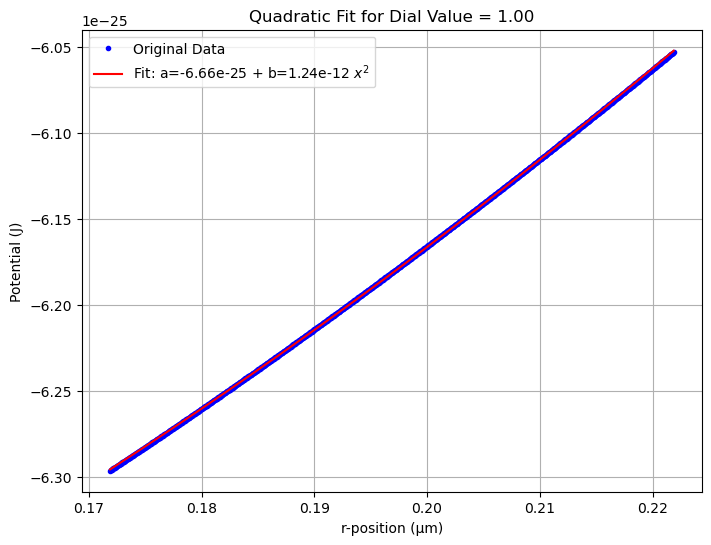

0.9710497730067457


In [33]:
# Select a specific dial value to plot (e.g., dial = 0.5)
dial_index = 10  # Index of the desired dial value (adjust as needed)
selected_dial = dial_values[dial_index]

# Extract the corresponding r_pos and ydata
r_pos_selected = r_pos_save[dial_index]
x_pos = r_pos_selected
y_pos = 0

# Recalculate ydata for the selected dial value
ydata_selected = potential_position_dependent(omega_res, linewidths, omega_tweezer, intensity(x_pos, y_pos, P0, wz))

# Perform the quadratic fit for the selected dial value
popt, pcov = curve_fit(quadratic, r_pos_selected, ydata_selected)

# Generate the fitted curve
fitted_curve = quadratic(r_pos_selected, *popt)

# Plot the original data and the fit
plt.figure(figsize=(8, 6))
plt.plot(r_pos_selected * 1e6, ydata_selected, 'b.', label='Original Data')  # Convert r_pos to µm for plotting
plt.plot(r_pos_selected * 1e6, fitted_curve, 'r-', label=f'Fit: a={popt[0]:.2e} + b={popt[1]:.2e} $x^2$')
plt.xlabel("r-position (µm)")
plt.ylabel("Potential (J)")
plt.title(f"Quadratic Fit for Dial Value = {selected_dial:.2f}")
plt.legend()
plt.grid(True)
plt.savefig(f"Quadratic_Fit_Dial_{selected_dial:.2f}.png")  # Save the plot
plt.show()
f_fit = (np.sqrt(2*popt[1]/m)/(2*pi)) * 1e-6
print(f_fit)

[6.424996212791408e-07]
[6.424996212791408e-07, 6.474018344575854e-07]
[6.424996212791408e-07, 6.474018344575854e-07, 6.520080955361792e-07]
[6.424996212791408e-07, 6.474018344575854e-07, 6.520080955361792e-07, 6.563444196724077e-07]
[6.424996212791408e-07, 6.474018344575854e-07, 6.520080955361792e-07, 6.563444196724077e-07, 6.604338597322278e-07]
[6.424996212791408e-07, 6.474018344575854e-07, 6.520080955361792e-07, 6.563444196724077e-07, 6.604338597322278e-07, 6.642969162569682e-07]
[6.424996212791408e-07, 6.474018344575854e-07, 6.520080955361792e-07, 6.563444196724077e-07, 6.604338597322278e-07, 6.642969162569682e-07, 6.679518811790632e-07]
[6.424996212791408e-07, 6.474018344575854e-07, 6.520080955361792e-07, 6.563444196724077e-07, 6.604338597322278e-07, 6.642969162569682e-07, 6.679518811790632e-07, 6.714151274496745e-07]
[6.424996212791408e-07, 6.474018344575854e-07, 6.520080955361792e-07, 6.563444196724077e-07, 6.604338597322278e-07, 6.642969162569682e-07, 6.679518811790632e-07, 6.

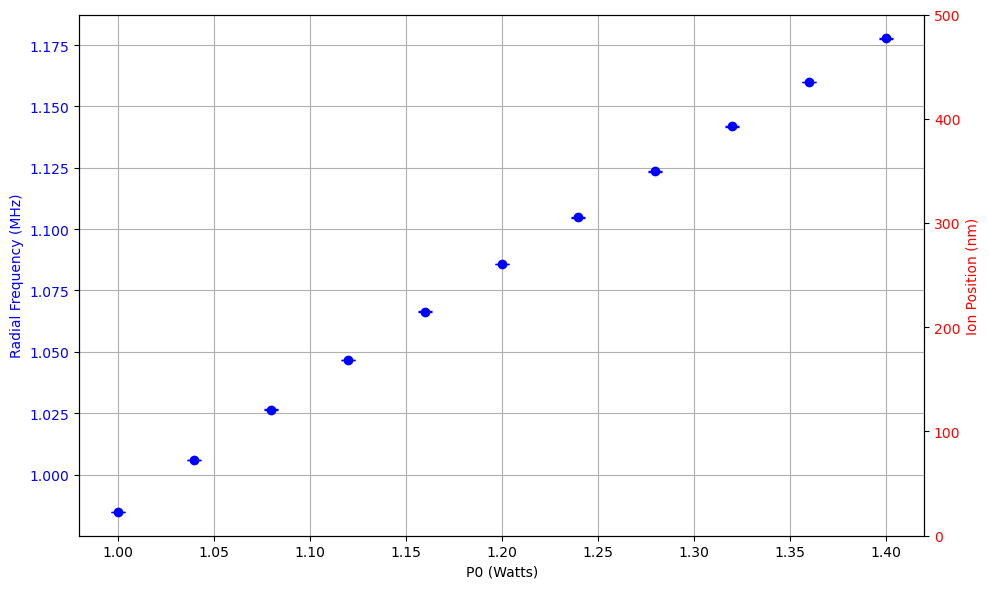

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Constants
P0_values = np.linspace(1, 1.4, 11)  # P0 values ranging from 1 W to 2 W
dial = 0.8  # Fixed dial value
w0 = 1e-6
lambda_beam = 532e-9
z_pos = 0
wz = beam_propogation(w0, z_pos, lambda_beam)
positions = []
r_pos_save = []
P0_analytical = 1  # Fixed P0 for analytical frequency calculation
results = []
frequencies = []  # To store the fit-based radial frequencies
errors = []  # To store the errors for the fit
num_points = 1000  # Fixed number of points for each P0 value

# Calculate the analytical frequency only once using P0_analytical
U = potential(omega_tweezer, linewidths, omega_res, P0_analytical, w0)
analytical = tweezer_optical_potential_to_trap_frequency(lambda_beam, linewidths, omega_res, P0_analytical, w0, m, U)

for P0 in P0_values:
    # Displacement and ion position
    displacement = w0 * dial
    U = potential(omega_tweezer, linewidths, omega_res, P0, w0)
    omega_tw_radial = tweezer_optical_potential_to_trap_frequency(omega_tweezer, linewidths, omega_res, P0, w0, m, U)[0]
    tweeze_on = fsolve(pot_derivative_with_tweeze, ionspacing[0], args=(omega_rf_axial, omega_tw_radial, tweezed_ion, displacement))
    positions.append(tweeze_on[0])
    print(positions)
    # Define r_pos for the current P0 value
    r_max = (w0 ) * (dial + dial * 0.025) - tweeze_on[0]
    r_min = (w0) * (dial - dial * 0.025) - tweeze_on[0]
    r_pos = np.linspace(r_min, r_max, num_points)

    # Recalculate ydata for each P0 value
    ydata = potential_position_dependent(omega_res, linewidths, omega_tweezer, intensity(r_pos, 0, P0, wz))

    # Use r_pos and ydata for fitting
    xdata = r_pos

    # Perform the fit for the potential
    popt, pcov = curve_fit(quadratic, xdata, ydata)

    # Calculate the fit-based radial frequency
    fit = np.sqrt(2 * popt[1] / m)

    # Estimate error from the covariance matrix for popt[1]
    perr = np.sqrt(np.diag(pcov))
    fit_error = np.abs(fit * (perr[1] / popt[1]))



    # Store the fit frequency and its error
    frequencies.append(fit * 1e-6 / (2 * np.pi))  # Convert to MHz
    errors.append(fit_error * 1e-6 / (2 * np.pi))  # Convert to MHz


# Convert positions to nanometers
positions = np.array(positions) * 1e9  # Convert to nm
# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot fit-based radial frequency on the left y-axis
ax1.errorbar(P0_values, frequencies, yerr=errors, fmt='o', label='Fit-Based Frequency', color='blue', capsize=5)
ax1.set_xlabel('P0 (Watts)')
ax1.set_ylabel('Radial Frequency (MHz)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Plot ion position on the right y-axis
ax2 = ax1.twinx()
ax2.plot(P0_values, positions, 'o', color='red', label='Ion Position')
ax2.set_ylabel('Ion Position (nm)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 500) # want this y-axis to match the other one 

# Add title and grid
ax1.grid(True)
fig.tight_layout()
plt.show()

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Select a specific dial value to plot (e.g., dial = 0.5)
dial_index = 0  # Index of the desired dial value (adjust as needed)
selected_dial = dial_values[dial_index]

# Extract the corresponding r_pos and ydata
r_pos_selected = r_pos_save[dial_index]
x_pos = r_pos_selected
y_pos = 0

# Recalculate ydata for the selected dial value
ydata_selected = potential_position_dependent(omega_res, linewidths, omega_tweezer, intensity(x_pos, y_pos, P0, wz))

# Perform the quadratic fit for the selected dial value
popt, pcov = curve_fit(quadratic, r_pos_selected, ydata_selected)

# Generate the fitted curve for the zoomed-in range
fitted_curve = quadratic(r_pos_selected, *popt)

# Plot the original data and the fit (zoomed-in plot)
plt.figure(figsize=(8, 6))
plt.plot(r_pos_selected * 1e6, ydata_selected, 'b.', label='Original Data')  # Convert r_pos to µm for plotting
plt.plot(r_pos_selected * 1e6, fitted_curve, 'r-', label=f'Fit: a={popt[0]:.2e} + b={popt[1]:.2e} $x^2$')
plt.xlabel("r-position (µm)")
plt.ylabel("Potential (J)")
plt.title(f"Quadratic Fit for Dial Value = {selected_dial:.2f}")
plt.legend()
plt.grid(True)
plt.show()

# Generate a new range for the zoomed-out plot
r_pos_zoomed_out = np.linspace(-1.5e-6, 1.5e-6, num_points)  # Range from -1.5 µm to 1.5 µm
ydata_zoomed_out = potential_position_dependent(omega_res, linewidths, omega_tweezer, intensity(r_pos_zoomed_out, 0, P0, wz))
fitted_curve_zoomed_out = quadratic(r_pos_zoomed_out, *popt)

# Plot the zoomed-out version
plt.figure(figsize=(8, 6))
plt.plot(r_pos_zoomed_out * 1e6, ydata_zoomed_out, 'b-', label='Potential (Gaussian)')  # Convert r_pos to µm for plotting
plt.plot(r_pos_zoomed_out * 1e6, fitted_curve_zoomed_out, 'r--', label=f'Quadratic Fit: a={popt[0]:.2e} + b={popt[1]:.2e} $x^2$')
plt.xlabel("r-position (µm)")
plt.ylabel("Potential (J)")
plt.title(f"Zoomed-Out Quadratic Fit for Dial Value = {selected_dial:.2f}")
plt.legend()
plt.grid(True)

# Set zoomed-out limits to match the range of r_pos_zoomed_out
plt.xlim(-1.5, 1.5)  # Set x-axis limits to match the zoomed-out range (in µm)
plt.ylim(min(ydata_zoomed_out) * 1.1, max(ydata_zoomed_out) * 1.1)  # Adjust y-axis limits to show more space
plt.savefig(f"Zoomed_Out_Quadratic_Fit_Dial_{selected_dial:.2f}.png")  # Save the zoomed-out plot
plt.show()

# Calculate and print the fit-based frequency
f_fit = (np.sqrt(2 * popt[1] / m) / (2 * np.pi)) * 1e-6
print(f_fit)

IndexError: list index out of range

# One tweezer but weaker power

In [ ]:
N = 9
tweezed_ions = [4]
w_rf_a = 2*pi*0.3e6
w_rf_r = 2*pi*2e6
ueq = ion_spacing(N, w_rf_a)[0]
P_opt = 100e-3
w0 = 1e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt,w0)
w_tw_a = omega_tweezer_a(U,beam_waist,tweezer_wavelength,m)
omeg_tweezer_a = np.zeros(N)
omeg_tweezer_a[tweezed_ions] = w_tw_a
omeg_rf_r = w_rf_r * np.ones(N)
omega_combined_ra = np.sqrt(omeg_rf_r**2 + omeg_tweezer_a**2)

ra_modes = mode_calc_r(m,omega_combined_ra,ueq,N)
radial_modes = physical_params_to_radial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
axial_modes = physical_params_to_axial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
etas_axial = eta(axial_modes,tweezer_wavelength,N)
etas_radial = eta(radial_modes,tweezer_wavelength,N)


# Convert axial_modes_base to a table
data_axial = {
    "Frequency (Hz)": [entry[0] for entry in axial_modes],
}
data_radial = {
    "Frequency (Hz)": [entry[0] for entry in radial_modes],
}
# Add columns for each component of the mode vectors
for i in range(len(etas_axial[0])):  # Iterate over the number of components in each mode vector
    data_axial[f"Component {i+1}"] = [eta[i] for eta in etas_axial]
for i in range(len(etas_radial[0])):  # Iterate over the number of components in each mode vector
    data_radial[f"Component {i+1}"] = [eta[i] for eta in etas_radial]

    

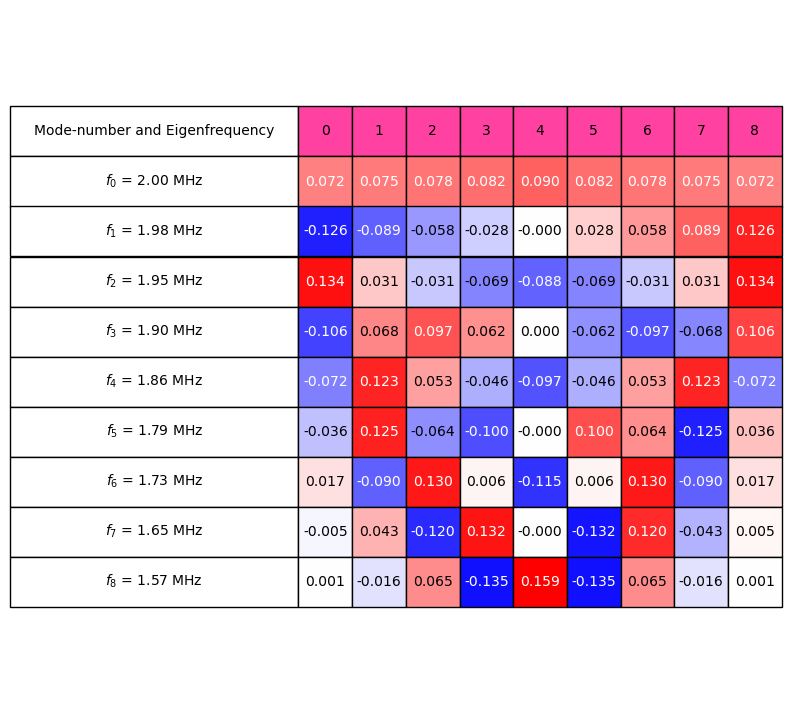

In [ ]:
fig, ax = plt.subplots(figsize=(1, 1 * len(radial_modes)))
ax.axis('tight')
ax.axis('off')

# Adding a table
table_data = []
for index, (omega, values) in enumerate(radial_modes):
    # Convert omega from radians per second to MHz
    omega_mhz = (omega  / 1e6)
    formatted_values = [f"{eta:.3f}" for eta in etas_radial[index]]  # Use etas_radial for the cell values
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ['Mode-number and Eigenfrequency'] + [f"{i}" for i in range(len(etas_radial[0]))]

# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(etas_radial[0]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=-max(max(etas_radial))-0.01, vmax=max(max(etas_radial))+0.01)

# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.07 < value < 0.07 else 'white')

# Set gray background for the first row, excluding the top left corner cell
for j in range(1, len(column_labels)):  # Skip the top left corner cell
    table[0, j].set_facecolor('#FF42A1')
table[0, 0].set_facecolor('white')  # Keep the top left corner cell white
#table[0,4].set_facecolor('gray') 

# Show the plot
plt.show()

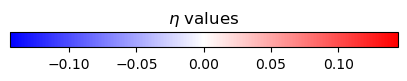

In [ ]:
# Create a figure and axis for the color bar
fig, ax = plt.subplots(figsize=(5,0.2))
fig.subplots_adjust(bottom=0.1)
plt.title("$\eta$ values")

# Create a color bar
cbar = mcolorbar.ColorbarBase(ax, cmap=cmap,
                              norm=norm,
                              orientation='horizontal')
# Add y-tick marks at the min and max

cbar.set_label('')
plt.show()

# one tweezer, but tweezer axial and trap radial

In [45]:
N = 9
tweezed_ions = [4]
w_rf_a = 2*pi*0.3e6
w_rf_r = 2*pi*2e6
ueq = ion_spacing(N, w_rf_a)[0]
P_opt = 100e-3
w0 = 1e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt,w0)
w_tw_a = omega_tweezer_a(U,beam_waist,tweezer_wavelength,m)
w_tw_r = omega_tweezer_r(U,beam_waist,m)
print(U)
print((w_tw_a/(2*pi))*1e-6)
print((w_tw_r/(2*pi))*1e-6)

omeg_tweezer_a = np.zeros(N)
omeg_tweezer_a[tweezed_ions] = w_tw_a
omeg_rf_r = w_rf_r * np.ones(N)
omega_combined_ra = np.sqrt(omeg_rf_r**2 + omeg_tweezer_a**2)

ra_modes = mode_calc_r(m,omega_combined_ra,ueq,N)
radial_modes = physical_params_to_radial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
axial_modes = physical_params_to_axial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
etas_axial = eta(axial_modes,tweezer_wavelength,N)
etas_radial = eta(radial_modes,tweezer_wavelength,N)
etas_ra = eta(ra_modes,tweezer_wavelength,N)


# Convert axial_modes_base to a table
data_axial = {
    "Frequency (Hz)": [entry[0] for entry in axial_modes],
}
data_radial = {
    "Frequency (Hz)": [entry[0] for entry in radial_modes],
}
data_ra = {
    "Frequency (Hz)": [entry[0] for entry in ra_modes],
}
# Add columns for each component of the mode vectors
for i in range(len(etas_axial[0])):  # Iterate over the number of components in each mode vector
    data_axial[f"Component {i+1}"] = [eta[i] for eta in etas_axial]
for i in range(len(etas_radial[0])):  # Iterate over the number of components in each mode vector
    data_radial[f"Component {i+1}"] = [eta[i] for eta in etas_radial]
for i in range(len(etas_ra[0])):  # Iterate over the number of components in each mode vector
    data_ra[f"Component {i+1}"] = [eta[i] for eta in etas_ra]
    

-6.679344769692264e-26
0.03823951742236945
0.3193490592467196


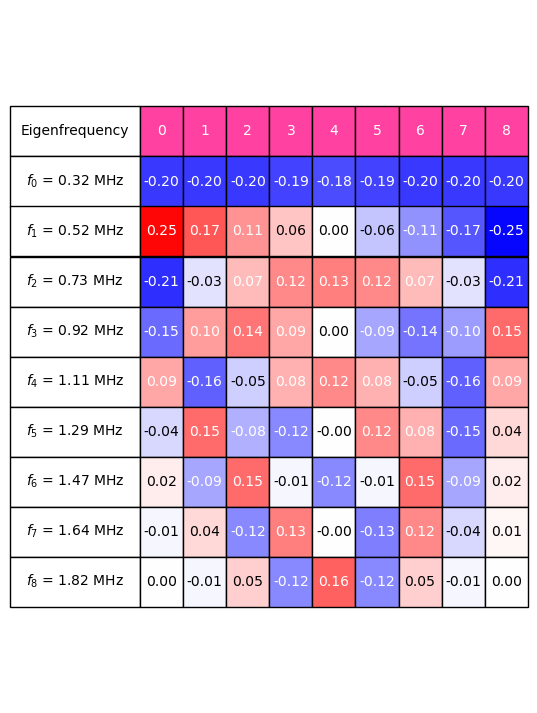

In [49]:
fig, ax = plt.subplots(figsize=(1, 1 * len(axial_modes)))
ax.axis('tight')
ax.axis('off')

# Adding a table
table_data = []
for index, (omega, values) in enumerate(axial_modes):
    # Convert omega from radians per second to MHz
    omega_mhz = (omega  / 1e6)
    formatted_values = [f"{eta:.2f}" for eta in etas_axial[index]]  # Use etas_radial for the cell values
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ['Eigenfrequency'] + [f"{i}" for i in range(len(etas_axial[0]))]

# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(etas_axial[0]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=-max(max(etas_axial))-0.01, vmax=max(max(etas_axial))+0.01)

# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.07 < value < 0.07 else 'white')
        table[0,i].set_text_props(color='white')  # Keep the first column text color black     

# Set gray background for the first row, excluding the top left corner cell
for j in range(1, len(column_labels)):  # Skip the top left corner cell
    table[0, j].set_facecolor('#FF42A1')
table[0, 0].set_facecolor('white')  # Keep the top left corner cell white
#table[0,4].set_facecolor('gray') 

# Show the plot
plt.show()

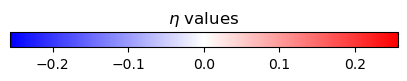

In [50]:
# Create a figure and axis for the color bar
fig, ax = plt.subplots(figsize=(5,0.2))
fig.subplots_adjust(bottom=0.1)
plt.title("$\eta$ values")

# Create a color bar
cbar = mcolorbar.ColorbarBase(ax, cmap=cmap,
                              norm=norm,
                              orientation='horizontal')
# Add y-tick marks at the min and max

cbar.set_label('')
plt.show()

# frequency scan for 422


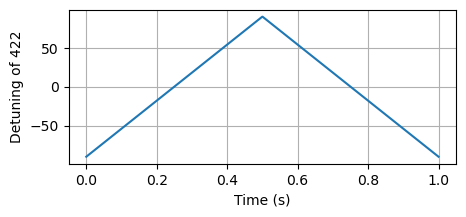

In [ ]:
from scipy.signal import sawtooth
import numpy as np
import matplotlib.pyplot as plt

# Parameters
frequency = 1  # Frequency in Hz
amplitude = 90  # Amplitude
time = np.linspace(0, 1, 1000)  # Time vector for 1 second

# Generate the symmetric sawtooth wave (up and down with equal slope)
y = amplitude * sawtooth(2 * np.pi * frequency * time, width=0.5)

# Plot the sawtooth wave
plt.figure(figsize=(5, 2))
plt.plot(time, y)
#plt.title("Symmetric Sawtooth Wave")
plt.xlabel("Time (s)")
plt.ylabel("Detuning of 422")
plt.grid(True)
plt.show()

# messing around with "idea" tweezers

In [ ]:
N = 9
tweezed_ions = [0,2,4,6,8]
w_rf_a = 2*pi*0.3e6
w_rf_r = 2*pi*2e6
ueq = ion_spacing(N, w_rf_a)[0]
P_opt = 1
w0 = 0.5e-6
U = potential(omega_tweezer,linewidths,omega_res,P_opt,w0)
radial_modes = physical_params_to_radial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
axial_modes = physical_params_to_axial_mode_vectors(N,ueq,tweezed_ions,tweezer_wavelength,linewidths,omega_res,w_rf_a,w_rf_r,P_opt,w0,m,U)
etas_axial = eta(axial_modes,tweezer_wavelength,N)
etas_radial = eta(radial_modes,tweezer_wavelength,N)


# Convert axial_modes_base to a table
data_axial = {
    "Frequency (Hz)": [entry[0] for entry in axial_modes],
}
data_radial = {
    "Frequency (Hz)": [entry[0] for entry in radial_modes],
}
# Add columns for each component of the mode vectors
for i in range(len(etas_axial[0])):  # Iterate over the number of components in each mode vector
    data_axial[f"Component {i+1}"] = [eta[i] for eta in etas_axial]
for i in range(len(etas_radial[0])):  # Iterate over the number of components in each mode vector
    data_radial[f"Component {i+1}"] = [eta[i] for eta in etas_radial]

    

[0, 2, 4, 6, 8]


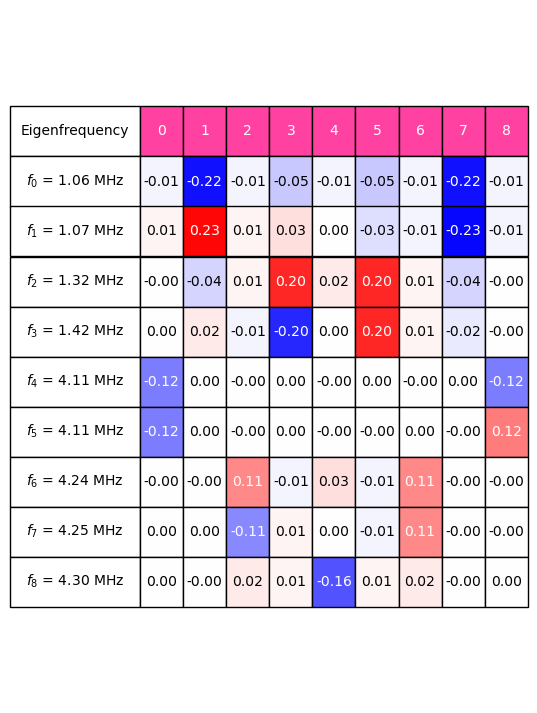

In [ ]:
fig, ax = plt.subplots(figsize=(1, 1 * len(axial_modes)))
ax.axis('tight')
ax.axis('off')

# Adding a table
table_data = []
for index, (omega, values) in enumerate(axial_modes):
    # Convert omega from radians per second to MHz
    omega_mhz = (omega  / 1e6)
    formatted_values = [f"{eta:.2f}" for eta in etas_axial[index]]  # Use etas_radial for the cell values
    omega_label = f"$f_{{{index}}}$ = {omega_mhz:.2f} MHz"
    table_data.append([omega_label] + formatted_values)

# Create column labels
column_labels = ['Eigenfrequency'] + [f"{i}" for i in range(len(etas_axial[0]))]

# The table
table = ax.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')

# Adjust font and cell size
table.auto_set_font_size(False)
table.set_fontsize(10)

# Adjusting column widths
colWidths = [0.3] * (len(etas_axial[0]) + 1)
colWidths[0] = 0.3  # Adjust the first column width as needed
table.auto_set_column_width(col=[i for i in range(len(colWidths))])

# Adjusting row heights
table.scale(1, 3)  # Increase the second argument to make rows taller

# Color map for background colors
cmap = plt.get_cmap('bwr')
norm = mcolors.Normalize(vmin=-max(max(etas_axial))-0.01, vmax=max(max(etas_axial))+0.01)

# Applying color to the value cells
for i, row in enumerate(table_data, start=1):
    for j in range(1, len(row)):
        value = float(row[j])
        color = cmap(norm(value))
        table[i, j].set_facecolor(color)
        table[i, j].set_text_props(color='black' if -0.07 < value < 0.07 else 'white')
        table[0,i].set_text_props(color='white')  # Keep the first column text color black        

# Set gray background for the first row, excluding the top left corner cell
for j in range(1, len(column_labels)):  # Skip the top left corner cell
    table[0, j].set_facecolor('#FF42A1')
table[0, 0].set_facecolor('white')  # Keep the top left corner cell white
#table[0,4].set_facecolor('gray') 
print(tweezed_ions)
# Show the plot
plt.show()